# Euclid Training and Inference Pipeline
Train on simulated data. Inference on real world data.

In [2]:
import os
from pathlib import Path

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.stats import sigma_clip
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scattering.coefficients import calculate_coefficients
from scripts.fit_models import get_folds
from scripts.obs_realism_hst import ObsRealism, normalise


## SNR calculation functions (provided by Carolin)


In [8]:
def get_sn(im_array, gain):
    """
    Calculate signal-to-noise for the object in an image
    This is the measure that should be run on all images to get this value
    to use instead of exposure time
    Gain, for HST use 1.6, 1.92 for Euclid
    """
    clipped = sigma_clip(im_array)
    _obj = clipped.data[clipped.mask]
    _sky = clipped.data[~clipped.mask]
    # Handle negative values that can occur after sky subtraction
    # Handle negative values that can occur after sky subtraction
    sky_sum = np.sum(_sky) * gain
    # Ensure non-negative for sqrt
    sn = np.sqrt(np.maximum(sky_sum, 0.0))
    return sn


def estimate_sky(im_array, gain=1.92):
    """
    Estimate the sky level in Euclid using the noise in the image
    This can be used to estimate the sky level that was subtracted off
    in the Euclid images
    Gain, for HST use 1.6, 1.92 for Euclid
    """
    clipped = sigma_clip(im_array)
    _obj = clipped.data[clipped.mask]
    _sky = clipped.data[~clipped.mask]
    sky = np.std(gain * _sky) ** 2 / gain
    return sky


## Load Euclid images and calculate SNR


In [9]:
def load_euclid_images(euclid_path, target_size=(128, 128)):
    """
    Load Euclid images and calculate SNR on flux values
    """
    euclid_path = Path(euclid_path)
    images = []
    filenames = []
    snrs = []

    for img_file in sorted(euclid_path.glob("*fits")):
        with fits.open(img_file) as hdul:
            img_data = hdul[0].data
            if img_data is None:
                img_data = hdul[1].data

        # Resize if needed (still on flux values)
        if img_data.shape != target_size:
            img_resized = cv2.resize(img_data, target_size, interpolation=cv2.INTER_LANCZOS4)
        else:
            img_resized = img_data

        # Calculate SNR on FLUX values with appropriate gain for Euclid
        snr = get_sn(img_resized, gain=1.92)

        # Store raw flux image
        images.append(img_data)
        filenames.append(img_file.name)
        snrs.append(snr)

    return np.array(images), filenames, np.array(snrs)


EUCLID_PATH = "../datasets/euclid"

print("Loading Euclid images and calculating SNRs")
euclid_images, euclid_filenames, euclid_snrs = load_euclid_images(EUCLID_PATH)

if len(euclid_images) > 0:
    median_snr = np.median(euclid_snrs)
    print(f"\nEuclid SNR Statistics:")
    print(f"  Median SNR: {median_snr:.2f}")
    print(f"  Mean SNR: {np.mean(euclid_snrs):.2f}")
    print(f"  SNR range: {np.min(euclid_snrs):.2f} - {np.max(euclid_snrs):.2f}")
    target_snr = median_snr
else:
    print("WARNING: No Euclid images loaded")

Loading Euclid images and calculating SNRs

Euclid SNR Statistics:
  Median SNR: 137.41
  Mean SNR: 172.37
  SNR range: 0.00 - 1696.30


## Apply observational realism to simulated data to match Euclid SNR


In [11]:
def apply_snr_matched_noise(input_path, target_snr, output_prefix="euclid_snr_matched", chunk_size=128):
    """
    Apply observational realism to simulated data to match target SNR from Euclid
    
    Steps:
    1. Load unnormalized simulated data
    2. Find exposure time that gives target SNR
    3. Apply noise using ObsRealism
    4. Normalize images
    """
    output_path = f"../datasets/tng_simulated_as_hst/{output_prefix}_SNR{int(target_snr)}_128x128_halfstellar32.hdf5"

    if os.path.exists(output_path):
        print(f"Existing dataset found at: {output_path}")
        return output_path

    print(f"\nCreating SNR-matched dataset (target SNR: {target_snr:.2f})")

    with h5py.File(input_path, 'r') as input_file:
        X = input_file["X"]
        arcsec_per_pixel = input_file["arcsec_per_pixel"][:]
        num_samples, num_projections, M, N = X.shape

        with h5py.File(output_path, 'w') as output_file:
            X_realistic = output_file.create_dataset(
                'X', shape=(num_samples, num_projections, M, N),
                dtype=np.float32, chunks=(chunk_size, num_projections, M, N)
            )

            for key in ['Y_ratio', 'Y_time', 'Y_stellar_mass', 'arcsec_per_pixel']:
                if key in input_file:
                    output_file.create_dataset(key, data=input_file[key][:])

            # Calibrate exposure time to match target SNR
            # Test on a sample image
            test_image = X[0, 0]
            test_arcsec = arcsec_per_pixel[0]

            low_exp, high_exp = 100, 10000
            for _ in range(30):
                mid_exp = (low_exp + high_exp) / 2
                test_noisy_flux = ObsRealism(test_image, test_arcsec, mid_exp, return_flux=True)

                # Calculate SNR on FLUX values (physically meaningful)
                test_snr = get_sn(test_noisy_flux, gain=1.92)

                if test_snr < target_snr:
                    low_exp = mid_exp
                else:
                    high_exp = mid_exp

            calibrated_exposure = (low_exp + high_exp) / 2
            print(f"Calibrated exposure time for SNR {target_snr:.2f}: {calibrated_exposure:.0f} seconds")

            # Process all images with calibrated exposure time
            for i in range(0, num_samples, chunk_size):
                end_idx = min(i + chunk_size, num_samples)

                X_chunk = X[i:end_idx]
                arcsec_chunk = arcsec_per_pixel[i:end_idx]

                for sample_idx in range(X_chunk.shape[0]):
                    for proj_idx in range(num_projections):
                        # Apply noise (input is unnormalized, on log scale)
                        im = ObsRealism(
                            X_chunk[sample_idx, proj_idx],
                            arcsec_chunk[sample_idx],
                            calibrated_exposure,
                            return_flux=True
                        )

                        # Log scale and normalize
                        im_log = np.log10(im)
                        im_norm = normalise(im_log)

                        X_chunk[sample_idx, proj_idx] = im_norm

                X_realistic[i:end_idx] = X_chunk

                if (end_idx) % 500 == 0:
                    print(f"Processed {end_idx} / {num_samples} samples")

            # Store calibration info
            output_file.attrs['target_snr'] = target_snr
            output_file.attrs['calibrated_exposure_time'] = calibrated_exposure

    print(f"\nSaved SNR-matched dataset to: {output_path}")
    return output_path


RAW_FILE = "../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5"

print("Applying observational realism to match Euclid SNR")
training_file = apply_snr_matched_noise(RAW_FILE, target_snr, output_prefix="fixed_euclid_snr_matched")


Applying observational realism to match Euclid SNR
Existing dataset found at: ../datasets/tng_simulated_as_hst/fixed_euclid_snr_matched_SNR137_128x128_halfstellar32.hdf5


In [12]:
def load_and_prepare_data(file_path):
    """
    Load and prepare data for training
    Expands projections: (n, 3, M, N) -> (n*3, M, N)
    """
    with h5py.File(file_path, 'r') as hf:
        X = hf["X"][:]  # (n, 3, M, N)
        Y_ratio = hf["Y_ratio"][:]
        Y_time = hf["Y_time"][:]
        Y_stellar_mass = hf["Y_stellar_mass"][:]

    n, p, M, N = X.shape
    X = X.reshape(n * p, M, N)  # (n*3, M, N)
    Y_stellar_mass = np.repeat(Y_stellar_mass, p)
    Y_time = np.repeat(Y_time, p)
    Y_ratio = np.repeat(Y_ratio, p)

    return X, Y_ratio, Y_time, Y_stellar_mass, M, N


# Load training data
print("Loading training data")
X_train_full, Y_ratio_full, Y_time_full, Y_stellar_mass_full, M, N = load_and_prepare_data(training_file)

print(f"Training data shape: {X_train_full.shape}")
print(f"Number of samples: {len(X_train_full)}")
print(f"Image size: {M}x{N}")


Loading training data
Training data shape: (25470, 128, 128)
Number of samples: 25470
Image size: 128x128


## Downsample data to balance target distribution


In [13]:
def downsample(X, y, y_stellar, other_variable=None, samples_per_bin=2000, n_bins=10, random_state=42):
    """
    Downsample data to balance target distribution by binning y values
    and sampling up to samples_per_bin from each bin.
    """
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    y_stellar = np.asarray(y_stellar)
    if other_variable is not None:
        other_variable = np.asarray(other_variable)

    # Remove non-finite values
    finite_mask = np.isfinite(y)
    if not finite_mask.all():
        X = X[finite_mask]
        y = y[finite_mask]
        y_stellar = y_stellar[finite_mask]
        if other_variable is not None:
            other_variable = other_variable[finite_mask]

    X = np.asarray(X)
    bins = np.linspace(np.min(y), np.max(y), n_bins)
    downsampled_X, downsampled_y, downsampled_y_stellar = [], [], []
    other_variables = [] if other_variable is not None else None

    for i in range(len(bins) - 1):
        lower, upper = bins[i], bins[i + 1]
        indices = np.where((y >= lower) & (y < upper))[0]
        if indices.size == 0:
            continue
        if len(indices) > samples_per_bin:
            indices = rng.choice(indices, samples_per_bin, replace=False)
        downsampled_X.append(X[indices])
        downsampled_y.append(y[indices])
        downsampled_y_stellar.append(y_stellar[indices])
        if other_variable is not None:
            other_variables.append(other_variable[indices])

    if len(downsampled_X) == 0:
        raise RuntimeError("Downsampling produced zero samples - check y values or bins.")
    X_out = np.concatenate(downsampled_X, axis=0)
    y_out = np.concatenate(downsampled_y, axis=0)
    y_stellar_out = np.concatenate(downsampled_y_stellar, axis=0)
    if other_variable is not None:
        other_out = np.concatenate(other_variables, axis=0)
        return X_out, y_out, y_stellar_out, other_out
    else:
        return X_out, y_out, y_stellar_out


## Train models for Y_Ratio and Y_time


In [ ]:
def train_model(X, y, y_stellar, other_variable, M, N, scattering_config, higher_config,
                output_name, samples_per_bin=2000, train_size=0.8, seed=42):
    # Downsample data to balance target distribution
    print(f"Downsampling data (samples_per_bin={samples_per_bin})...")
    X_down, y_down, y_stellar_down, other_variable_down = downsample(
        X, y, y_stellar, other_variable,
        samples_per_bin=samples_per_bin, n_bins=10, random_state=seed
    )
    print(f"Downsampled data shape: {X_down.shape}")
    print(f"Target distribution: min={np.min(y_down):.3f}, max={np.max(y_down):.3f}, mean={np.mean(y_down):.3f}")

    # Calculate scattering coefficients
    print(f"Calculating scattering coefficients...")
    scattering_coef, y_down = calculate_coefficients(
        X_down, y_down, M, N, scattering_config, higher_config, output_name, "scattering"
    )

    print(f"Scattering coefficients shape: {scattering_coef.shape}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        scattering_coef, y_down, train_size=train_size, random_state=seed
    )

    print(f"Train set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Setup pipeline
    param_grid = {
        "regressor__n_neighbors": [7],
    }

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', KNeighborsRegressor(p=1, weights="distance")),
    ])

    # Cross-validation folds
    cross_val_folds = get_folds(X_train)

    # Grid search
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cross_val_folds,
        n_jobs=4,
        verbose=1,
        scoring="neg_mean_absolute_error"
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")

    # Evaluate on test set
    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    print(f"\nTest Set Performance:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")

    return best_model, mae, rmse, y_test, y_pred


# Scattering configuration (from notebook)
scattering_config = {
    "L": 10,
    "J": 6,
    "sigma": 0.5,
    "lp_norms": [0.5, 1, 2],
    "bispectrum": True,
    "bicoherence": True,
    "reduce": True
}
higher_config = scattering_config.copy()

# Train Y_Ratio model
print("Training Y_Ratio model")
model_ratio, mae_ratio, rmse_ratio, y_test_ratio, y_pred_ratio = train_model(
    X_train_full, Y_ratio_full, Y_stellar_mass_full, Y_time_full, M, N,
    scattering_config, higher_config, "euclid_ratio",
    samples_per_bin=2000, train_size=0.8, seed=42
)

print(f"Achieved: MAE {mae_ratio:.4f}, RMSE {rmse_ratio:.4f}")

# Train Y_time model
print("Training Y_time model")
model_time, mae_time, rmse_time, y_test_time, y_pred_time = train_model(
    X_train_full, Y_time_full, Y_stellar_mass_full, Y_ratio_full, M, N,
    scattering_config, higher_config, "euclid_time",
    samples_per_bin=2000, train_size=0.8, seed=42
)

print(f"Achieved: MAE {mae_time:.4f}, RMSE {rmse_time:.4f}")

## Preprocess Euclid images for inference


In [ ]:
def preprocess_euclid_for_inference(euclid_images, target_size=(128, 128)):
    processed_images = []

    for img in euclid_images:
        # Handle negative values that may exist after sky subtraction
        img_positive = img - np.min(img) + 1e-10

        # Resize if needed
        if img.shape != target_size:
            img_resized = cv2.resize(img_positive, target_size, interpolation=cv2.INTER_LANCZOS4)
        else:
            img_resized = img_positive

        img_log = np.log10(img_resized)
        img_log = np.nan_to_num(img_log, nan=0.0,
                                posinf=np.max(img_log[np.isfinite(img_log)]) if np.any(np.isfinite(img_log)) else 0.0,
                                neginf=0.0)

        img_norm = normalise(img_log)
        processed_images.append(img_norm)

    return np.array(processed_images)


# Preprocess Euclid images
print("Preprocessing Euclid images for inference")

euclid_processed = preprocess_euclid_for_inference(euclid_images)
print(f"Processed {len(euclid_processed)} images, shape: {euclid_processed.shape}")

## Perform inference on Euclid images


In [ ]:
def perform_inference(euclid_processed, euclid_filenames, euclid_snrs,
                      model_ratio, model_time, scattering_config, higher_config, M, N):
    print(f"\nPerforming inference on {len(euclid_processed)} images...")

    # Calculate scattering coefficients for Euclid images
    print("Calculating scattering coefficients for Euclid images...")
    euclid_coef, _ = calculate_coefficients(
        euclid_processed, np.zeros(len(euclid_processed)), M, N,
        scattering_config, higher_config, "euclid_inference", "scattering"
    )

    print(f"Scattering coefficients shape: {euclid_coef.shape}")
    print("Running predictions...")
    ratio_predictions = model_ratio.predict(euclid_coef)
    time_predictions = model_time.predict(euclid_coef)

    # Create results dataframe
    results_df = pd.DataFrame({
        'filename': euclid_filenames,
        'snr': euclid_snrs,
        'mass_ratio_log10': ratio_predictions,
        'mass_ratio': 10 ** ratio_predictions,
        'time_since_merger_gyr': time_predictions,
        'image_index': np.arange(len(euclid_filenames))
    })

    return results_df.sort_values('mass_ratio', ascending=False).reset_index(drop=True)


print("Performing inference on Euclid images")

results_df = perform_inference(
    euclid_processed, euclid_filenames, euclid_snrs,
    model_ratio, model_time, scattering_config, higher_config, M, N
)

# Print summary
print("INFERENCE RESULTS SUMMARY")
print(f"{'=' * 60}")
print(f"\nTotal galaxies analyzed: {len(results_df)}")
print(f"\nMass Ratio Statistics (log10):")
print(f"  Mean:   {results_df['mass_ratio_log10'].mean():.3f}")
print(f"  Median: {results_df['mass_ratio_log10'].median():.3f}")
print(f"  Range:  {results_df['mass_ratio_log10'].min():.3f} to {results_df['mass_ratio_log10'].max():.3f}")

print(f"\nTime Since Merger Statistics (Gyr):")
print(f"  Mean:   {results_df['time_since_merger_gyr'].mean():.3f}")
print(f"  Median: {results_df['time_since_merger_gyr'].median():.3f}")
print(f"  Range:  {results_df['time_since_merger_gyr'].min():.3f} to {results_df['time_since_merger_gyr'].max():.3f}")



## Save predictions


In [14]:
OUTPUT_DIR = Path("./results/euclid_inference")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_path = OUTPUT_DIR / "euclid_predictions.csv"

# if results_df:
#     results_df.to_csv(output_path, index=False)

results_df = pd.read_csv(output_path)

## Prediction Distribution Analysis

In [15]:
# Original TNG, not downsampled
Y_orig = np.column_stack([
    Y_time_full,
    Y_ratio_full  # already log10(mass ratio)
])

# Downsampled time and mass ratio
_, time_down, _ = downsample(
    X_train_full,
    y=Y_time_full,
    y_stellar=Y_stellar_mass_full,
    samples_per_bin=2000,
    n_bins=10,
    random_state=42
)
_, mass_ratio_down, _ = downsample(
    X_train_full,
    y=Y_ratio_full,
    y_stellar=Y_stellar_mass_full,
    samples_per_bin=2000,
    n_bins=10,
    random_state=42
)

n = min(len(time_down), len(mass_ratio_down))
time_down, mass_ratio_down = time_down[:n], mass_ratio_down[:n]
Y_down = np.column_stack([time_down, mass_ratio_down])

# Predicted
Y_euclid = np.column_stack([
    results_df['time_since_merger_gyr'].values,
    results_df['mass_ratio_log10'].values
])


def fit_2d_gaussian(Y):
    mu = np.mean(Y, axis=0)
    cov = np.cov(Y.T)

    cov += np.eye(2) * 1e-6 * np.trace(cov)
    return mu, cov


def kl_gaussian(mu0, cov0, mu1, cov1):
    k = len(mu0)
    inv_cov1 = np.linalg.inv(cov1)
    diff = mu1 - mu0

    return 0.5 * (
            np.trace(inv_cov1 @ cov0)
            + diff.T @ inv_cov1 @ diff
            - k
            + np.log(np.linalg.det(cov1) / np.linalg.det(cov0))
    )


mu_orig, cov_orig = fit_2d_gaussian(Y_orig)
mu_down, cov_down = fit_2d_gaussian(Y_down)
mu_euc, cov_euc = fit_2d_gaussian(Y_euclid)

kl_orig_euclid = kl_gaussian(mu_orig, cov_orig, mu_euc, cov_euc)
kl_orig_down = kl_gaussian(mu_orig, cov_orig, mu_down, cov_down)

print(f"KL(original    || Euclid predictions) = {kl_orig_euclid:.4f}")
print(f"KL(original    || downsampled)        = {kl_orig_down:.4f}")


KL(original    || Euclid predictions) = 13.5890
KL(original    || downsampled)        = 22.9757


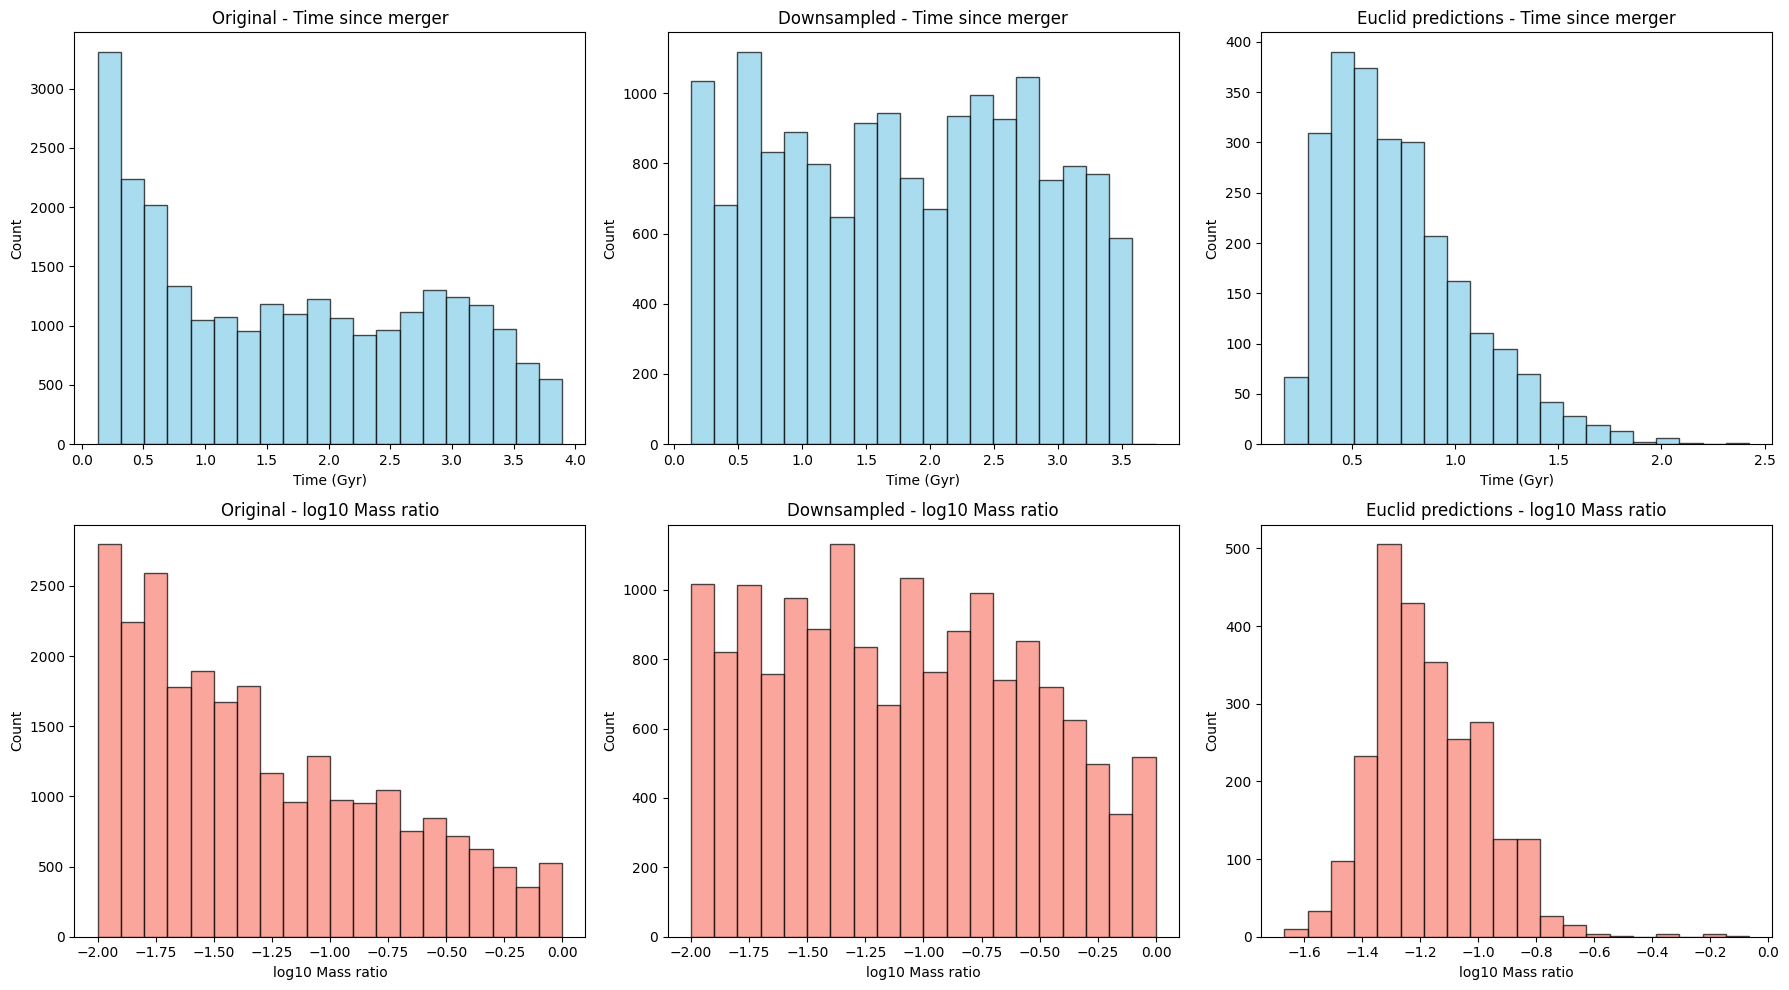

In [16]:


def plot_target_histograms(Y_orig, Y_down, Y_euclid, bins_time=20, bins_mass=20):
    datasets = {
        "Original": Y_orig,
        "Downsampled": Y_down,
        "Euclid predictions": Y_euclid
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, (label, Y) in enumerate(datasets.items()):
        # Time
        axes[0, i].hist(Y[:, 0], bins=bins_time, color='skyblue', edgecolor='black', alpha=0.7)
        axes[0, i].set_title(f"{label} - Time since merger")
        axes[0, i].set_xlabel("Time (Gyr)")
        axes[0, i].set_ylabel("Count")

        # Mass
        axes[1, i].hist(Y[:, 1], bins=bins_mass, color='salmon', edgecolor='black', alpha=0.7)
        axes[1, i].set_title(f"{label} - log10 Mass ratio")
        axes[1, i].set_xlabel("log10 Mass ratio")
        axes[1, i].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


plot_target_histograms(Y_orig, Y_down, Y_euclid)
